   pump_id  risk_score risk_level  well_id
0        1       0.277        Low        1
1        2       0.140        Low        1
2        3       0.040        Low        2
3        4       0.100        Low        3
4        5       0.055        Low        5


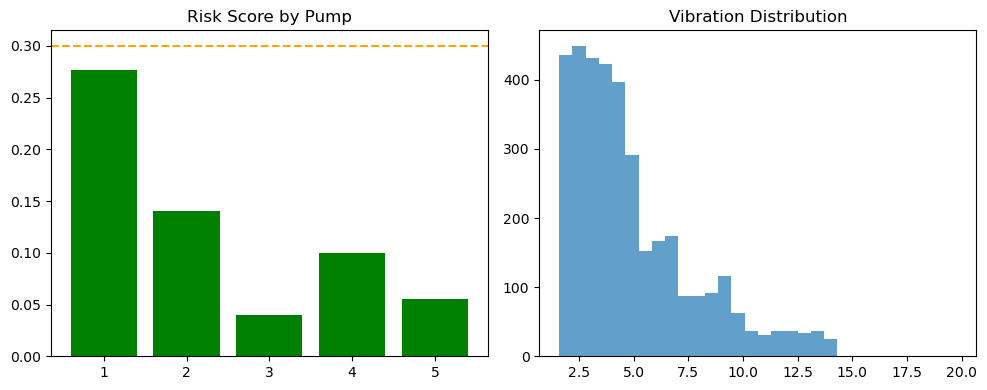

{'ResponseMetadata': {'RequestId': '18B2C854D9F75502',
  'HostId': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'content-length': '0',
   'etag': '"aeea3a98f471e7d0373f66de975e3b87"',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-checksum-crc32': 'mI1n2Q==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'x-amz-id-2': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
   'x-amz-request-id': '18B2C854D9F75502',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '1964',
   'x-ratelimit-remaining': '1964',
   'x-xss-protection': '1; mode=block',
   'date': 'Mon, 25 May 2026 10:31:09 GMT'},
  'RetryAttempts': 0},
 'ETag': '"aeea3a98f471e7d0373f66de975e3b87"',
 'ChecksumCRC32': 'mI1n2Q==',
 'ChecksumType': 'FULL_OBJECT'}

In [1]:
# 05_anomaly_detection.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import boto3
from botocore.client import Config
import io
from datetime import timedelta

s3 = boto3.client('s3', endpoint_url='http://minio:9000', aws_access_key_id='minioadmin', aws_secret_access_key='minioadmin123', config=Config(signature_version='s3v4'))

def read(key):
    resp = s3.get_object(Bucket='oil-data-lake', Key=key)
    return pd.read_parquet(io.BytesIO(resp['Body'].read()))

sensors = read('raw/pump_sensors.parquet')
failures = read('raw/pump_failures.parquet')
pumps = read('raw/pumps.parquet')

sensor_cols = ['temperature', 'vibration', 'current', 'rpm', 'pressure']
scaler = StandardScaler()
sensors_scaled = scaler.fit_transform(sensors[sensor_cols])

iso_forest = IsolationForest(contamination=0.05, random_state=42)
sensors['anomaly'] = iso_forest.fit_predict(sensors_scaled)
sensors['is_anomaly'] = sensors['anomaly'] == -1

risk_data = []
for _, failure in failures.iterrows():
    f_time = pd.to_datetime(failure['failure_date'])
    for h in [1, 3, 6, 12, 24]:
        sample_time = f_time - timedelta(hours=h)
        sample = sensors[(sensors['pump_id'] == failure['pump_id']) & (pd.to_datetime(sensors['timestamp']) == sample_time)]
        if not sample.empty:
            s = sample.iloc[0].to_dict()
            s['risk'] = 1
            risk_data.append(s)

normal = sensors[~sensors['is_anomaly']].sample(n=min(len(risk_data)*2, 1000), random_state=42).copy()
normal['risk'] = 0

all_risk = pd.concat([pd.DataFrame(risk_data), normal], ignore_index=True)
X_risk = all_risk[sensor_cols]
y_risk = all_risk['risk']

scaler_risk = StandardScaler()
X_scaled = scaler_risk.fit_transform(X_risk)

rf_risk = RandomForestClassifier(n_estimators=100, random_state=42)
rf_risk.fit(X_scaled, y_risk)

last_sensors = sensors.groupby('pump_id').last().reset_index()
X_current = scaler_risk.transform(last_sensors[sensor_cols])
risk_scores = rf_risk.predict_proba(X_current)[:, 1]

risk_df = pd.DataFrame({'pump_id': last_sensors['pump_id'], 'risk_score': risk_scores.round(3)})
risk_df['risk_level'] = pd.cut(risk_scores, bins=[0, 0.3, 0.7, 1], labels=['Low', 'Medium', 'High'])
risk_df = risk_df.merge(pumps[['pump_id', 'well_id']], on='pump_id')

print(risk_df)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(risk_df['pump_id'], risk_df['risk_score'], color=['green' if x < 0.3 else 'orange' for x in risk_df['risk_score']])
plt.axhline(y=0.3, color='orange', linestyle='--')
plt.title('Risk Score by Pump')
plt.subplot(1, 2, 2)
plt.hist(sensors['vibration'], bins=30, alpha=0.7)
plt.title('Vibration Distribution')
plt.tight_layout()
plt.savefig('anomaly_charts.png')
plt.show()

buf = io.BytesIO()
risk_df.to_parquet(buf, index=False)
buf.seek(0)
s3.put_object(Bucket='oil-data-lake', Key='predictions/risk_assessment.parquet', Body=buf.getvalue())